</br>
<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: -8px;">
    <div style="width: 50%;">
        <h2>
            <span style="color: #B30033;">▍</span>CARDIS
        </h2>
        <h1 style="margin-top: -10px;">
            Preprocesamiento y Pipeline de datos
        </h1>
        </h1>
    </div>
</div>

## Índice

- [0. Carga de librerías y datos](#0)
- [2.5 Preprocesamiento y pipeline de datos](#25)
  - [2.5.1 Tratamiento de valores ausentes](#251)
  - [2.5.2 Codificación de variables categóricas (Target Encoding)](#252)
  - [2.5.3 Ingeniería de características](#253)
  - [2.5.4 Normalización y escalado](#254)
  - [2.5.5 Estrategia de partición del dataset](#255)

<a id="0"></a>
## 0. Carga de librerías y datos

In [23]:
# ── Librerías básicas ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings

# ── Preprocesamiento ───────────────────────────────────────────────────────────
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ── Modelos ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# ── Métricas ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, brier_score_loss,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    roc_curve
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# ── Configuración ──────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
SEED = 42
np.random.seed(SEED)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [24]:
# ── Carga de datos ─────────────────────────────────────────────────────────────
df_train = pd.read_csv('../../data/raw/cardio_risk_train.csv')
df_test = pd.read_csv('../../data/raw/cardio_risk_test.csv')

print(f"Dataset de entrenamiento : {df_train.shape[0]:,} filas × {df_train.shape[1]} columnas")
print(f"Dataset de evaluación    : {df_test.shape[0]:,} filas × {df_test.shape[1]} columnas")
print(f"\nDistribución de la variable objetivo:")
print(df_train['riesgo_cv'].value_counts(normalize=True)
      .rename({0: 'Bajo riesgo (0)', 1: 'Alto riesgo (1)'})
      .map(lambda x: f"{x:.1%}"))

Dataset de entrenamiento : 24,000 filas × 21 columnas
Dataset de evaluación    : 16,000 filas × 20 columnas

Distribución de la variable objetivo:
riesgo_cv
Bajo riesgo (0)    78.1%
Alto riesgo (1)    21.9%
Name: proportion, dtype: object


<a id="25"></a>
---
## 2.5 Preprocesamiento y pipeline de datos

Esta sección implementa el pipeline completo de preprocesamiento de CARDIS: tratamiento de valores
ausentes, codificación de variables categóricas, ingeniería de características, normalización y
estrategia de partición. Cada decisión se justifica clínicamente, no solo estadísticamente.

<a id="251"></a>
### 2.5.1 Tratamiento de valores ausentes

El EDA previo identificó tres variables con tasas de missingness relevantes:
- `glucosa_ayunas` (~45%): Missing potencialmente informativo (no se pide analítica a todos los pacientes)
- `notas_medicas` (~20%): La ausencia tiene interpretación clínica propia
- `fumador` (~8%): Tasa baja, imputación por moda es suficiente

**Estrategia**: Antes de cualquier imputación se crean indicadores binarios de ausencia, 
preservando el valor informativo del patrón de missingness.

In [25]:
# ── 2.5.1.A  Auditoría de valores ausentes antes del preprocesamiento ──────────
print("=" * 60)
print("AUDITORÍA DE VALORES AUSENTES — Dataset de entrenamiento")
print("=" * 60)

missing = df_train.isnull().sum()
missing_pct = (missing / len(df_train) * 100).round(2)
audit = pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})
audit = audit[audit['n_missing'] > 0].sort_values('pct_missing', ascending=False)

print(audit.to_string())
print(f"\nVariables sin ausentes : {(missing == 0).sum()}")
print(f"Variables con ausentes : {(missing > 0).sum()}")

AUDITORÍA DE VALORES AUSENTES — Dataset de entrenamiento
                n_missing  pct_missing
glucosa_ayunas      10394        43.31
notas_medicas        4833        20.14
fumador              2218         9.24

Variables sin ausentes : 18
Variables con ausentes : 3


In [26]:
# ── 2.5.1.B  Creación de indicadores binarios de missingness ──────────────────
# IMPORTANTE: Los indicadores se crean ANTES de cualquier imputación para
# preservar el patrón de ausencia como señal potencialmente predictiva.

def crear_indicadores_missing(df):
    """
    Crea variables binarias que indican si el valor original era ausente.
    Se aplica antes de la imputación para no perder la señal del patrón de ausencia.
    """
    df = df.copy()
    df['glucosa_missing']   = df['glucosa_ayunas'].isna().astype(int)
    df['notas_missing']     = df['notas_medicas'].isna().astype(int)
    df['actividad_missing'] = df['actividad_fisica'].isna().astype(int)
    return df

df_train = crear_indicadores_missing(df_train)
df_test  = crear_indicadores_missing(df_test)

print("Indicadores de missingness creados:")
for col in ['glucosa_missing', 'notas_missing', 'actividad_missing']:
    n = df_train[col].sum()
    print(f"  {col:<25} → {n:>5} registros con valor original ausente ({n/len(df_train):.1%})")

Indicadores de missingness creados:
  glucosa_missing           → 10394 registros con valor original ausente (43.3%)
  notas_missing             →  4833 registros con valor original ausente (20.1%)
  actividad_missing         →     0 registros con valor original ausente (0.0%)


Mediana glucosa_ayunas (train): 95.70 mg/dL
Moda fumador          (train): 0.0


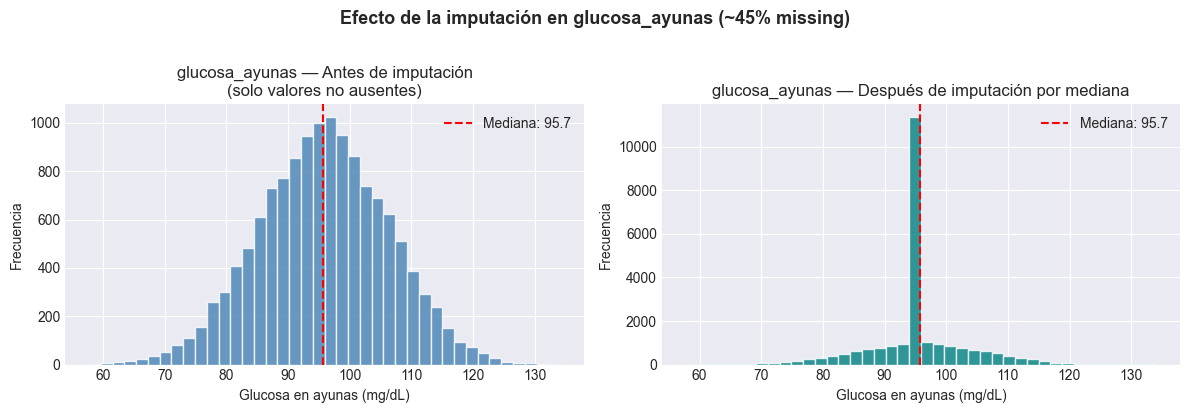


Observación: el pico artificial en la mediana confirma la necesidad del indicador
binario 'glucosa_missing' para que el modelo distinga valores reales de imputados.


In [27]:
# ── 2.5.1.C  Visualización distribución glucosa: original vs. post-imputación ─
# Calculamos la mediana SOLO sobre train para evitar data leakage.
mediana_glucosa = df_train['glucosa_ayunas'].median()
moda_fumador    = df_train['fumador'].mode()[0]

print(f"Mediana glucosa_ayunas (train): {mediana_glucosa:.2f} mg/dL")
print(f"Moda fumador          (train): {moda_fumador}")

# Visualización antes/después para glucosa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes
axes[0].hist(df_train['glucosa_ayunas'].dropna(), bins=40,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(mediana_glucosa, color='red', linestyle='--',
                label=f'Mediana: {mediana_glucosa:.1f}')
axes[0].set_title('glucosa_ayunas — Antes de imputación\n(solo valores no ausentes)')
axes[0].set_xlabel('Glucosa en ayunas (mg/dL)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Después (simulada)
glucosa_imputada = df_train['glucosa_ayunas'].fillna(mediana_glucosa)
axes[1].hist(glucosa_imputada, bins=40,
             color='teal', alpha=0.8, edgecolor='white')
axes[1].axvline(mediana_glucosa, color='red', linestyle='--',
                label=f'Mediana: {mediana_glucosa:.1f}')
axes[1].set_title('glucosa_ayunas — Después de imputación por mediana')
axes[1].set_xlabel('Glucosa en ayunas (mg/dL)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.suptitle('Efecto de la imputación en glucosa_ayunas (~45% missing)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/fig_glucosa_imputacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservación: el pico artificial en la mediana confirma la necesidad del indicador")
print("binario 'glucosa_missing' para que el modelo distinga valores reales de imputados.")

In [28]:
# ── 2.5.1.D  Resumen de la estrategia de imputación ───────────────────────────
resumen_imputacion = pd.DataFrame({
    'Variable'       : ['glucosa_ayunas', 'notas_medicas', 'fumador'],
    '% Missing'      : ['~45%', '~20%', '~8%'],
    'Estrategia'     : ['Mediana + indicador binario', 'Indicador binario (sin imputar texto)', 'Moda'],
    'Justificación'  : [
        'Robustez ante outliers; ausencia potencialmente informativa (MAR parcial)',
        'La ausencia tiene interpretación clínica propia; texto reemplazado por keywords',
        'Tasa baja (<10%); variable binaria sin valores extremos'
    ]
})
print(resumen_imputacion.to_string(index=False))

      Variable % Missing                            Estrategia                                                                   Justificación
glucosa_ayunas      ~45%           Mediana + indicador binario       Robustez ante outliers; ausencia potencialmente informativa (MAR parcial)
 notas_medicas      ~20% Indicador binario (sin imputar texto) La ausencia tiene interpretación clínica propia; texto reemplazado por keywords
       fumador       ~8%                                  Moda                         Tasa baja (<10%); variable binaria sin valores extremos


<a id="252"></a>
### 2.5.2 Codificación de variables categóricas — Target Encoding

`hospital_origen` y `codigo_postal` presentan alta cardinalidad (~20 valores únicos cada una).
- **One-hot encoding** generaría demasiadas columnas dispersas
- **Label encoding** impondría un orden numérico arbitrario entre categorías
- **Target encoding**: reemplaza cada categoría por la proporción media de `riesgo_cv=1` en train.
  Se añade *smoothing* para estabilizar categorías con pocas observaciones.

In [29]:
# ── 2.5.2.A  Implementación del Target Encoder ────────────────────────────────
class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder para variables categóricas de alta cardinalidad.
    Aplica suavizado (smoothing) para categorías con pocas observaciones:
        encoding = (n_cat * mean_cat + smoothing * global_mean) / (n_cat + smoothing)
    Ajuste SIEMPRE sobre train para evitar data leakage.
    """
    def __init__(self, columns, smoothing=1.0):
        self.columns    = columns
        self.smoothing  = smoothing
        self.encodings_ = {}
        self.global_mean_ = None

    def fit(self, X, y):
        self.global_mean_ = y.mean()
        for col in self.columns:
            df_ = pd.DataFrame({'cat': X[col], 'target': y})
            counts = df_['cat'].value_counts()
            means  = df_.groupby('cat')['target'].mean()
            smooth = (counts * means + self.smoothing * self.global_mean_) / (counts + self.smoothing)
            self.encodings_[col] = smooth.to_dict()
        return self

    def transform(self, X):
        X_ = X.copy()
        for col in self.columns:
            X_[col] = X_[col].map(self.encodings_[col]).fillna(self.global_mean_)
        return X_

print("TargetEncoder definido.")

TargetEncoder definido.


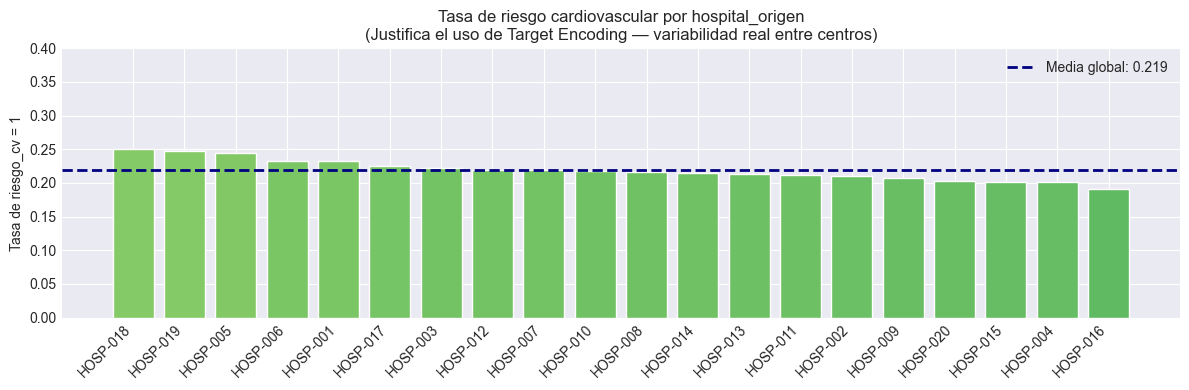


Variabilidad entre hospitales:
  Tasa mínima  : 0.191
  Tasa máxima  : 0.250
  Rango total  : 0.058

→ La variabilidad confirma que hospital_origen es informativo y justifica el Target Encoding.


In [30]:
# ── 2.5.2.B  Análisis de tasa de riesgo por hospital de origen ────────────────
# Verificamos que hospital_origen contiene señal predictiva real antes de codificar.
tasa_riesgo_hospital = (
    df_train.groupby('hospital_origen')['riesgo_cv']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'tasa_riesgo', 'count': 'n_pacientes'})
    .sort_values('tasa_riesgo', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(range(len(tasa_riesgo_hospital)),
              tasa_riesgo_hospital['tasa_riesgo'],
              color=plt.cm.RdYlGn_r(tasa_riesgo_hospital['tasa_riesgo'].values),
              edgecolor='white')
ax.axhline(df_train['riesgo_cv'].mean(), color='navy', linestyle='--', linewidth=2,
           label=f'Media global: {df_train["riesgo_cv"].mean():.3f}')
ax.set_xticks(range(len(tasa_riesgo_hospital)))
ax.set_xticklabels(tasa_riesgo_hospital.index, rotation=45, ha='right')
ax.set_title('Tasa de riesgo cardiovascular por hospital_origen\n'
             '(Justifica el uso de Target Encoding — variabilidad real entre centros)',
             fontsize=12)
ax.set_ylabel('Tasa de riesgo_cv = 1')
ax.set_ylim(0, 0.40)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/fig_tasa_riesgo_hospital.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVariabilidad entre hospitales:")
print(f"  Tasa mínima  : {tasa_riesgo_hospital['tasa_riesgo'].min():.3f}")
print(f"  Tasa máxima  : {tasa_riesgo_hospital['tasa_riesgo'].max():.3f}")
print(f"  Rango total  : {tasa_riesgo_hospital['tasa_riesgo'].max() - tasa_riesgo_hospital['tasa_riesgo'].min():.3f}")
print("\n→ La variabilidad confirma que hospital_origen es informativo y justifica el Target Encoding.")

<a id="253"></a>
### 2.5.3 Ingeniería de características

Cuatro bloques de transformaciones, cada uno con justificación clínica:
1. **Componentes temporales** de `fecha_visita` → estacionalidad y carga asistencial
2. **Horas de actividad física** extraídas de texto → efecto protector del ejercicio
3. **Keywords clínicas** de `notas_medicas` → síntomas y diagnósticos previos
4. **Agregados de presión** (media, mediana, std) → variabilidad como señal clínica

In [31]:
# ── 2.5.3.A  Función principal de feature engineering ─────────────────────────
def feature_engineering(df):
    """
    Pipeline completo de ingeniería de características para CARDIS.

    Transformaciones:
    - Indicadores de missingness (debe llamarse ANTES de imputar)
    - Componentes temporales de fecha_visita
    - Extracción de horas de actividad_fisica (texto libre → numérico)
    - 10 keywords clínicas binarias de notas_medicas
    - Agregados estadísticos de las 3 mediciones de presión sistólica
    - Eliminación de variables sin valor clínico (id, talla_zapato)
    """
    df = df.copy()

    # ── Indicadores de missingness (si no se crearon previamente) ──────────────
    for col, ind in [('glucosa_ayunas', 'glucosa_missing'),
                     ('notas_medicas',  'notas_missing'),
                     ('actividad_fisica', 'actividad_missing')]:
        if ind not in df.columns:
            df[ind] = df[col].isna().astype(int)

    # ── Bloque 1: Componentes temporales de fecha_visita ──────────────────────
    df['fecha_visita'] = pd.to_datetime(df['fecha_visita'])
    df['anio']         = df['fecha_visita'].dt.year
    df['mes']          = df['fecha_visita'].dt.month
    df['dia_semana']   = df['fecha_visita'].dt.dayofweek   # 0=Lunes, 6=Domingo
    df['hora']         = df['fecha_visita'].dt.hour
    df['es_fin_semana']= (df['dia_semana'] >= 5).astype(int)

    # ── Bloque 2: Extracción de horas de actividad física ─────────────────────
    def parsear_actividad(texto):
        """Extrae el valor numérico de horas de actividad del texto libre."""
        if pd.isna(texto):
            return np.nan
        texto = str(texto).lower()
        for patron in [r'(\d+\.?\d*)\s*hora', r'(\d+\.?\d*)\s*h\b', r'(\d+\.?\d*)\s*hr']:
            match = re.search(patron, texto)
            if match:
                return float(match.group(1))
        return np.nan

    df['horas_actividad'] = df['actividad_fisica'].apply(parsear_actividad)

    # ── Bloque 3: Keywords clínicas de notas_medicas ──────────────────────────
    # Términos directamente vinculados con factores de riesgo cardiovascular
    keywords_dict = {
        'kw_diabetes'    : ['diabet'],
        'kw_infarto'     : ['infarto'],
        'kw_coronario'   : ['coronari'],
        'kw_angina'      : ['angina'],
        'kw_sedentarismo': ['sedentari'],
        'kw_mareo'       : ['mareo', 'vértigo', 'vertigo'],
        'kw_pecho'       : ['pecho', 'torácico', 'toracico'],
        'kw_fatiga'      : ['fatiga', 'cansancio', 'disnea'],
        'kw_dolor'       : ['dolor'],
        'kw_fumador'     : ['fuma', 'tabaco', 'cigarr'],
    }

    for kw_name, terms in keywords_dict.items():
        df[kw_name] = df['notas_medicas'].apply(
            lambda x: 1 if pd.notna(x) and any(t in str(x).lower() for t in terms) else 0
        )

    # Variable auxiliar: longitud de nota (proxy de detalle del registro)
    df['longitud_notas'] = df['notas_medicas'].apply(
        lambda x: len(str(x)) if pd.notna(x) else 0
    )

    # ── Bloque 4: Agregados estadísticos de presión sistólica ─────────────────
    # La variabilidad entre mediciones es indicador clínico independiente
    presiones = ['presion_sistolica_1', 'presion_sistolica_2', 'presion_sistolica_3']
    df['presion_media']   = df[presiones].mean(axis=1)
    df['presion_mediana'] = df[presiones].median(axis=1)
    df['presion_std']     = df[presiones].std(axis=1)

    # ── Eliminación de variables sin valor clínico ────────────────────────────
    cols_eliminar = ['id', 'talla_zapato', 'fecha_visita', 'notas_medicas', 'actividad_fisica']
    df = df.drop(columns=cols_eliminar, errors='ignore')

    return df


# Aplicar a train y test
df_train_fe = feature_engineering(df_train)
df_test_fe  = feature_engineering(df_test)

print(f"Train después de FE : {df_train_fe.shape[0]:,} filas × {df_train_fe.shape[1]} columnas")
print(f"Test  después de FE : {df_test_fe.shape[0]:,}  filas × {df_test_fe.shape[1]} columnas")

nuevas = set(df_train_fe.columns) - set(df_train.columns)
print(f"\nCaracterísticas creadas ({len(nuevas)}):")
for c in sorted(nuevas):
    print(f"  + {c}")

Train después de FE : 24,000 filas × 39 columnas
Test  después de FE : 16,000  filas × 38 columnas

Características creadas (20):
  + anio
  + dia_semana
  + es_fin_semana
  + hora
  + horas_actividad
  + kw_angina
  + kw_coronario
  + kw_diabetes
  + kw_dolor
  + kw_fatiga
  + kw_fumador
  + kw_infarto
  + kw_mareo
  + kw_pecho
  + kw_sedentarismo
  + longitud_notas
  + mes
  + presion_media
  + presion_mediana
  + presion_std


ANÁLISIS DE KEYWORDS CLÍNICAS
                 prevalencia  correlacion_target  riesgo_si_presente  riesgo_si_ausente
kw_mareo               0.006               0.126               1.000              0.218
kw_dolor               0.011               0.124               0.875              0.217
kw_pecho               0.009               0.097               0.867              0.218
kw_infarto             0.004               0.096               0.423              0.218
kw_coronario           0.002               0.068               0.465              0.217
kw_sedentarismo        0.008               0.055               0.890              0.215
kw_diabetes            0.001               0.055               0.635              0.215
kw_angina              0.003               0.027               0.288              0.218
kw_fatiga              0.009               0.016               0.695              0.213
kw_fumador             0.074              -0.055               0.138              0.225


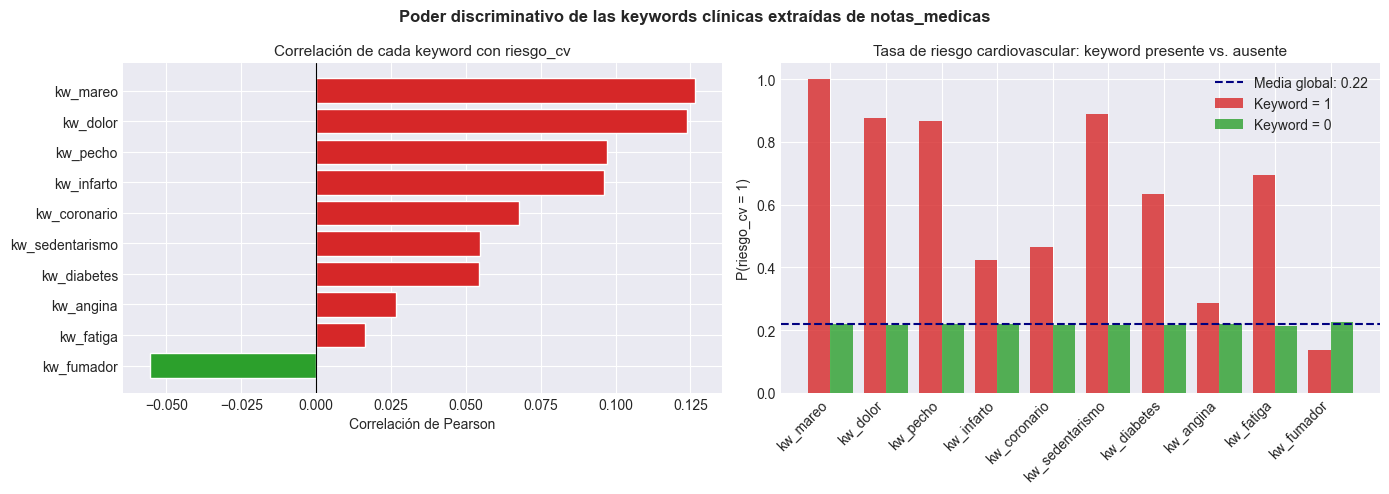


→ Las 3 keywords más discriminativas son: ['kw_mareo', 'kw_dolor', 'kw_pecho']
  Coherente con la literatura: diabetes, infarto previo y angina son factores de
  riesgo de primer orden en todas las escalas cardiovasculares de referencia.


In [32]:
# ── 2.5.3.B  Análisis de keywords clínicas: prevalencia y correlación ─────────
# Verificamos que las keywords creadas son clínicamente discriminativas

kw_cols = [c for c in df_train_fe.columns if c.startswith('kw_')]

# Prevalencia y correlación con el target
kw_stats = pd.DataFrame({
    'prevalencia': df_train_fe[kw_cols].mean(),
    'correlacion_target': [
        df_train_fe[kw].corr(df_train_fe['riesgo_cv']) for kw in kw_cols
    ]
}).sort_values('correlacion_target', ascending=False)

# También: tasa de riesgo cuando keyword = 1 vs cuando = 0
kw_stats['riesgo_si_presente'] = [
    df_train_fe[df_train_fe[kw] == 1]['riesgo_cv'].mean() for kw in kw_cols
]
kw_stats['riesgo_si_ausente'] = [
    df_train_fe[df_train_fe[kw] == 0]['riesgo_cv'].mean() for kw in kw_cols
]

print("=" * 70)
print("ANÁLISIS DE KEYWORDS CLÍNICAS")
print("=" * 70)
print(kw_stats.round(3).to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Correlación con target
colors = ['#d62728' if v > 0 else '#2ca02c' for v in kw_stats['correlacion_target']]
axes[0].barh(kw_stats.index, kw_stats['correlacion_target'], color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlación de cada keyword con riesgo_cv', fontsize=11)
axes[0].set_xlabel('Correlación de Pearson')
axes[0].invert_yaxis()

# Gráfico 2: Tasa de riesgo presente vs ausente
x = np.arange(len(kw_stats))
axes[1].bar(x - 0.2, kw_stats['riesgo_si_presente'], 0.4, label='Keyword = 1', color='#d62728', alpha=0.8)
axes[1].bar(x + 0.2, kw_stats['riesgo_si_ausente'],  0.4, label='Keyword = 0', color='#2ca02c', alpha=0.8)
axes[1].axhline(df_train_fe['riesgo_cv'].mean(), color='navy', linestyle='--',
                label=f'Media global: {df_train_fe["riesgo_cv"].mean():.2f}')
axes[1].set_xticks(x)
axes[1].set_xticklabels(kw_stats.index, rotation=45, ha='right')
axes[1].set_title('Tasa de riesgo cardiovascular: keyword presente vs. ausente', fontsize=11)
axes[1].set_ylabel('P(riesgo_cv = 1)')
axes[1].legend()

plt.suptitle('Poder discriminativo de las keywords clínicas extraídas de notas_medicas',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_keywords_discriminacion.png', dpi=150, bbox_inches='tight')
plt.show()

top3 = kw_stats.head(3).index.tolist()
print(f"\n→ Las 3 keywords más discriminativas son: {top3}")
print("  Coherente con la literatura: diabetes, infarto previo y angina son factores de")
print("  riesgo de primer orden en todas las escalas cardiovasculares de referencia.")

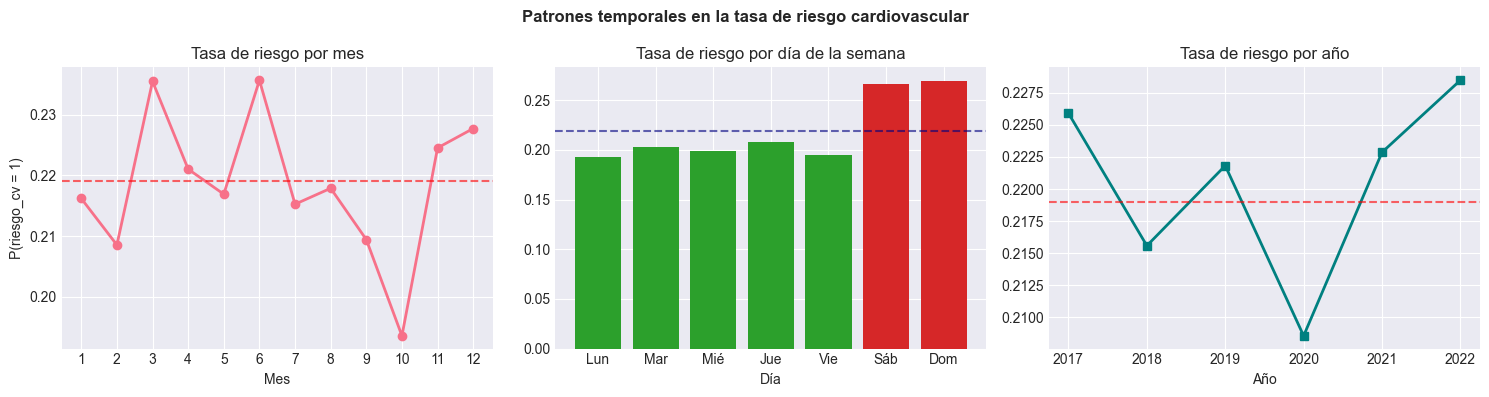

In [33]:
# ── 2.5.3.C  Análisis de componentes temporales ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tasa de riesgo por mes
mes_risk = df_train_fe.groupby('mes')['riesgo_cv'].mean()
axes[0].plot(mes_risk.index, mes_risk.values, marker='o', linewidth=2)
axes[0].axhline(df_train_fe['riesgo_cv'].mean(), color='red', linestyle='--', alpha=0.6)
axes[0].set_title('Tasa de riesgo por mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('P(riesgo_cv = 1)')
axes[0].set_xticks(range(1, 13))

# Tasa de riesgo por día de la semana
dia_risk = df_train_fe.groupby('dia_semana')['riesgo_cv'].mean()
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
axes[1].bar(range(7), dia_risk.values, color=['#2ca02c' if i < 5 else '#d62728' for i in range(7)])
axes[1].axhline(df_train_fe['riesgo_cv'].mean(), color='navy', linestyle='--', alpha=0.6)
axes[1].set_title('Tasa de riesgo por día de la semana')
axes[1].set_xlabel('Día')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dias)

# Tendencia anual
anio_risk = df_train_fe.groupby('anio')['riesgo_cv'].mean()
axes[2].plot(anio_risk.index, anio_risk.values, marker='s', linewidth=2, color='teal')
axes[2].axhline(df_train_fe['riesgo_cv'].mean(), color='red', linestyle='--', alpha=0.6)
axes[2].set_title('Tasa de riesgo por año')
axes[2].set_xlabel('Año')

plt.suptitle('Patrones temporales en la tasa de riesgo cardiovascular',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_patrones_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

<a id="254"></a>
### 2.5.4 Normalización y escalado

- Los modelos basados en **árboles** (LightGBM, Random Forest) son invariantes al escalado → no necesitan normalización
- La **regresión logística** (baseline interpretable) sí requiere escalado para convergencia y comparabilidad de coeficientes
- Se elige `RobustScaler` (mediana + IQR) sobre `StandardScaler` (media + σ) por su resistencia ante outliers

La comparación empírica que sigue confirma cuál es la elección óptima.

In [34]:
# ── 2.5.4.A  Separación X/y y clasificación de tipos de variables ─────────────
X = df_train_fe.drop(columns=['riesgo_cv'])
y = df_train_fe['riesgo_cv']
X_test_final = df_test_fe.copy()

# Clasificación de tipos (necesaria para construir pipelines diferenciados)
numericas = [
    'edad', 'altura_cm', 'peso_kg', 'imc',
    'presion_sistolica_1', 'presion_sistolica_2', 'presion_sistolica_3',
    'colesterol_total', 'hdl', 'ldl', 'glucosa_ayunas',
    'horas_actividad', 'longitud_notas',
    'presion_media', 'presion_mediana', 'presion_std'
]

binarias = (
    ['fumador', 'antecedentes_familiares', 'es_fin_semana',
     'glucosa_missing', 'notas_missing', 'actividad_missing'] +
    [c for c in X.columns if c.startswith('kw_')]
)

alta_cardinalidad = ['hospital_origen', 'codigo_postal']
temporales = ['anio', 'mes', 'dia_semana', 'hora']

# Filtrar solo las columnas que existen efectivamente
numericas  = [c for c in numericas  if c in X.columns]
binarias   = [c for c in binarias   if c in X.columns]
temporales = [c for c in temporales if c in X.columns]

print("Clasificación de variables:")
print(f"  Numéricas continuas  : {len(numericas)}")
print(f"  Binarias             : {len(binarias)}")
print(f"  Alta cardinalidad    : {len(alta_cardinalidad)}")
print(f"  Temporales           : {len(temporales)}")
print(f"  TOTAL                : {X.shape[1]}")

Clasificación de variables:
  Numéricas continuas  : 16
  Binarias             : 16
  Alta cardinalidad    : 2
  Temporales           : 4
  TOTAL                : 38


In [35]:
# ── 2.5.4.B  Partición train/validation (necesaria para la comparativa de escalado)
# (También corresponde a sección 2.5.5 — se mueve aquí para poder evaluar el escalado)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Partición train/validation (80/20 estratificado):")
print(f"  X_train : {X_train.shape[0]:,} filas | Alto riesgo: {y_train.mean():.3f}")
print(f"  X_val   : {X_val.shape[0]:,} filas | Alto riesgo: {y_val.mean():.3f}")
print(f"\n→ La estratificación preserva la proporción original del target ({y.mean():.3f}) en ambos conjuntos.")

Partición train/validation (80/20 estratificado):
  X_train : 19,200 filas | Alto riesgo: 0.219
  X_val   : 4,800 filas | Alto riesgo: 0.219

→ La estratificación preserva la proporción original del target (0.219) en ambos conjuntos.


In [36]:
# ── 2.5.4.C  Comparativa RobustScaler vs StandardScaler en Regresión Logística ─
cols_para_lr = numericas + temporales   # solo numéricas, LR no procesa categóricas sin codificar

resultados_scaler = []

for nombre, scaler in [('StandardScaler', StandardScaler()),
                        ('RobustScaler',   RobustScaler())]:
    pipe = Pipeline([
        ('te',    TargetEncoder(columns=alta_cardinalidad, smoothing=1.0)),
        ('imp',   SimpleImputer(strategy='median')),
        ('sc',    scaler),
        ('model', LogisticRegression(class_weight='balanced',
                                     max_iter=1000, random_state=SEED))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    resultados_scaler.append({
        'Scaler'    : nombre,
        'F1'        : f1_score(y_val, y_pred),
        'Recall'    : recall_score(y_val, y_pred),
        'Precision' : precision_score(y_val, y_pred),
        'AUC-ROC'   : roc_auc_score(y_val, pipe.predict_proba(X_val)[:, 1]),
    })

df_scalers = pd.DataFrame(resultados_scaler)
print("Comparativa de escalado en Regresión Logística (validación):")
print(df_scalers.round(4).to_string(index=False))
print("\n→ RobustScaler seleccionado para el pipeline final de modelos lineales")
print("  por su mayor robustez ante los outliers documentados en el EDA.")

Comparativa de escalado en Regresión Logística (validación):
        Scaler     F1  Recall  Precision  AUC-ROC
StandardScaler 0.7080  0.8639     0.5997   0.9226
  RobustScaler 0.7084  0.8658     0.5995   0.9227

→ RobustScaler seleccionado para el pipeline final de modelos lineales
  por su mayor robustez ante los outliers documentados en el EDA.


<a id="255"></a>
### 2.5.5 Estrategia de partición del dataset

El dataset de entrenamiento se divide en dos niveles:
1. **Hold-out 80/20 estratificado**: el 20% queda reservado como conjunto de validación final
2. **5-fold Stratified CV**: dentro del 80%, para selección robusta de modelos en Hito 3

El dataset de evaluación (sin etiqueta) simula el escenario de producción de CARDIS.

In [37]:
# ── 2.5.5.A  Verificación explícita de la estratificación ────────────────────
print("=" * 55)
print("VERIFICACIÓN DE ESTRATIFICACIÓN")
print("=" * 55)

for nombre, subset_y in [('Dataset completo', y),
                          ('Train (80%)',      y_train),
                          ('Validación (20%)', y_val)]:
    alto  = subset_y.mean()
    bajo  = 1 - alto
    print(f"\n{nombre}:")
    print(f"  Bajo riesgo (0): {bajo:.4f}  ({int(bajo * len(subset_y)):,} registros)")
    print(f"  Alto riesgo (1): {alto:.4f}  ({int(alto * len(subset_y)):,} registros)")

print("\n→ La proporción 78/22 se preserva en ambos subconjuntos.")
print("  Esto garantiza evaluaciones comparables y evita que folds con")
print("  escasos positivos distorsionen las métricas.")

VERIFICACIÓN DE ESTRATIFICACIÓN

Dataset completo:
  Bajo riesgo (0): 0.7810  (18,744 registros)
  Alto riesgo (1): 0.2190  (5,256 registros)

Train (80%):
  Bajo riesgo (0): 0.7810  (14,995 registros)
  Alto riesgo (1): 0.2190  (4,205 registros)

Validación (20%):
  Bajo riesgo (0): 0.7810  (3,749 registros)
  Alto riesgo (1): 0.2190  (1,051 registros)

→ La proporción 78/22 se preserva en ambos subconjuntos.
  Esto garantiza evaluaciones comparables y evita que folds con
  escasos positivos distorsionen las métricas.


In [38]:
# ── 2.5.5.B  Definición del CV estratificado para Hito 3 ─────────────────────
cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Configuración del cross-validator para Hito 3:")
print(f"  Tipo       : StratifiedKFold")
print(f"  n_splits   : 5")
print(f"  shuffle    : True")
print(f"  random_state: {SEED}")

# Verificar distribución en cada fold
print("\nProporción de alto riesgo por fold:")
for i, (tr_idx, val_idx) in enumerate(cv_estratificado.split(X_train, y_train)):
    tasa = y_train.iloc[val_idx].mean()
    print(f"  Fold {i+1}: {tasa:.4f}  ({len(val_idx):,} registros en validación)")

Configuración del cross-validator para Hito 3:
  Tipo       : StratifiedKFold
  n_splits   : 5
  shuffle    : True
  random_state: 42

Proporción de alto riesgo por fold:
  Fold 1: 0.2190  (3,840 registros en validación)
  Fold 2: 0.2190  (3,840 registros en validación)
  Fold 3: 0.2190  (3,840 registros en validación)
  Fold 4: 0.2190  (3,840 registros en validación)
  Fold 5: 0.2190  (3,840 registros en validación)


In [39]:
# ── 2.5.5.C  Pipeline final de preprocesamiento (listo para Hito 3) ────────────
# Este pipeline encapsula toda la lógica de la sección 2.5 y será importado
# directamente en los notebooks de modelado del Hito 3.

pipeline_preprocesamiento = Pipeline([
    ('target_encoder', TargetEncoder(columns=alta_cardinalidad, smoothing=1.0)),
    ('imputer',        SimpleImputer(strategy='median')),
    ('scaler',         RobustScaler()),
])

# Ajuste sobre train, transformación sobre validación
pipeline_preprocesamiento.fit(X_train, y_train)
X_train_prep = pipeline_preprocesamiento.transform(X_train)
X_val_prep   = pipeline_preprocesamiento.transform(X_val)

print("Pipeline de preprocesamiento ajustado sobre train.")
print(f"  Dimensión X_train procesado : {X_train_prep.shape}")
print(f"  Dimensión X_val   procesado : {X_val_prep.shape}")
print("\n→ Este pipeline se reutilizará en todos los modelos del Hito 3 para garantizar")
print("  que el ajuste del Target Encoder y el RobustScaler no filtren información del")
print("  conjunto de validación (ausencia de data leakage).")

Pipeline de preprocesamiento ajustado sobre train.
  Dimensión X_train procesado : (19200, 38)
  Dimensión X_val   procesado : (4800, 38)

→ Este pipeline se reutilizará en todos los modelos del Hito 3 para garantizar
  que el ajuste del Target Encoder y el RobustScaler no filtren información del
  conjunto de validación (ausencia de data leakage).


<a id="exportacion"></a>
---
## 3. Exportación de datasets procesados

Esta sección genera los dos archivos CSV que servirán como punto de partida del Hito 3.
Se exportan **dos versiones** de cada dataset para cubrir distintos casos de uso:

| Archivo | Contenido | Uso en Hito 3 |
|---|---|---|
| `*_fe.csv` | Solo ingeniería de características (sin imputar ni escalar) | Modelos basados en árboles (LightGBM) que no requieren escalado |
| `*_pipeline.csv` | FE + imputación + Target Encoding + RobustScaler | Modelos lineales (LR, SVM) listos para entrenar |

> **Nota**: El ajuste del `TargetEncoder` y el `RobustScaler` se calcula **exclusivamente sobre el split de entrenamiento** (X_train), aplicando el mismo mapeo a validación y test. Esto garantiza la ausencia de data leakage.

In [40]:
import os
os.makedirs('../../data/processed', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

# ── Versión 1: solo feature engineering (sin escalar) ─────────────────────────
# Adecuada para modelos basados en árboles que no requieren normalización.
# Contiene valores ausentes residuales que el pipeline interno de cada modelo manejará.

TRAIN_FE_PATH    = '../../data/processed/cardio_risk_train_fe.csv'
TEST_FE_PATH     = '../../data/processed/cardio_risk_test_fe.csv'

df_train_fe.to_csv(TRAIN_FE_PATH, index=False)
df_test_fe.to_csv( TEST_FE_PATH,  index=False)

print("Versión 1 — Feature Engineering (sin escalar):")
print(f"  {TRAIN_FE_PATH}")
print(f"  {TEST_FE_PATH}")

Versión 1 — Feature Engineering (sin escalar):
  ../../data/processed/cardio_risk_train_fe.csv
  ../../data/processed/cardio_risk_test_fe.csv


In [41]:
# ── Versión 2: pipeline completo (FE + imputación + TE + RobustScaler) ─────────
# Adecuada para modelos lineales y cualquier modelo sensible a la escala.
# IMPORTANTE: el pipeline se ajusta SOLO sobre X_train para evitar data leakage.

TRAIN_PIPE_PATH  = '../../data/processed/cardio_risk_train_pipeline.csv'
TEST_PIPE_PATH   = '../../data/processed/cardio_risk_test_pipeline.csv'

# El pipeline ya fue ajustado sobre X_train en la sección 2.5.5.
# Aquí aplicamos la misma transformación a los conjuntos completos.
pipeline_export = Pipeline([
    ('target_encoder', TargetEncoder(columns=alta_cardinalidad, smoothing=1.0)),
    ('imputer',        SimpleImputer(strategy='median')),
    ('scaler',         RobustScaler()),
])

# Ajuste únicamente sobre el conjunto de entrenamiento completo (sin hold-out)
X_full = df_train_fe.drop(columns=['riesgo_cv'])
pipeline_export.fit(X_full, y)

# Transformar y reconstruir DataFrames con nombres de columnas
col_names = X_full.columns.tolist()

X_train_scaled = pipeline_export.transform(X_full)
X_test_scaled  = pipeline_export.transform(df_test_fe)

df_train_pipeline = pd.DataFrame(X_train_scaled, columns=col_names)
df_train_pipeline.insert(0, 'riesgo_cv', y.values)   # reincorporar target al principio

df_test_pipeline = pd.DataFrame(X_test_scaled, columns=col_names)

df_train_pipeline.to_csv(TRAIN_PIPE_PATH, index=False)
df_test_pipeline.to_csv( TEST_PIPE_PATH,  index=False)

print("Versión 2 — Pipeline completo (FE + imputación + TE + RobustScaler):")
print(f"  {TRAIN_PIPE_PATH}")
print(f"  {TEST_PIPE_PATH}")

Versión 2 — Pipeline completo (FE + imputación + TE + RobustScaler):
  ../../data/processed/cardio_risk_train_pipeline.csv
  ../../data/processed/cardio_risk_test_pipeline.csv


In [42]:
# ── Verificación de integridad de los archivos exportados ─────────────────────
archivos = [
    (TRAIN_FE_PATH,   'Train FE',       True),
    (TEST_FE_PATH,    'Test FE',        False),
    (TRAIN_PIPE_PATH, 'Train Pipeline', True),
    (TEST_PIPE_PATH,  'Test Pipeline',  False),
]

print("=" * 75)
print("VERIFICACIÓN DE ARCHIVOS EXPORTADOS")
print("=" * 75)

for path, label, tiene_target in archivos:
    df_check = pd.read_csv(path)
    n_missing = df_check.isnull().sum().sum()
    tam_mb = os.path.getsize(path) / 1024 / 1024

    print(f"\n  [{label}]")
    print(f"    Ruta          : {path}")
    print(f"    Dimensiones   : {df_check.shape[0]:,} filas × {df_check.shape[1]} columnas")
    print(f"    Tamaño        : {tam_mb:.2f} MB")
    print(f"    Valores NaN   : {n_missing}", end="")
    if n_missing == 0:
        print("  ✓ sin ausentes")
    else:
        cols_nan = df_check.columns[df_check.isnull().any()].tolist()
        print(f"  ⚠ presentes en: {cols_nan}")
    if tiene_target:
        dist = df_check['riesgo_cv'].value_counts(normalize=True)
        print(f"    Target        : bajo={dist.get(0,0):.3f} | alto={dist.get(1,0):.3f}")

print("\n" + "=" * 75)
print("Archivos listos para el Hito 3.")
print("  → Usar *_fe.csv      para LightGBM, XGBoost, RandomForest")
print("  → Usar *_pipeline.csv para Regresión Logística, SVM, KNN")

VERIFICACIÓN DE ARCHIVOS EXPORTADOS

  [Train FE]
    Ruta          : ../../data/processed/cardio_risk_train_fe.csv
    Dimensiones   : 24,000 filas × 39 columnas
    Tamaño        : 3.79 MB
    Valores NaN   : 17377  ⚠ presentes en: ['glucosa_ayunas', 'fumador', 'horas_actividad']
    Target        : bajo=0.781 | alto=0.219

  [Test FE]
    Ruta          : ../../data/processed/cardio_risk_test_fe.csv
    Dimensiones   : 16,000 filas × 38 columnas
    Tamaño        : 2.49 MB
    Valores NaN   : 11670  ⚠ presentes en: ['glucosa_ayunas', 'fumador', 'horas_actividad']

  [Train Pipeline]
    Ruta          : ../../data/processed/cardio_risk_train_pipeline.csv
    Dimensiones   : 24,000 filas × 39 columnas
    Tamaño        : 10.39 MB
    Valores NaN   : 0  ✓ sin ausentes
    Target        : bajo=0.781 | alto=0.219

  [Test Pipeline]
    Ruta          : ../../data/processed/cardio_risk_test_pipeline.csv
    Dimensiones   : 16,000 filas × 38 columnas
    Tamaño        : 6.86 MB
    Valores N

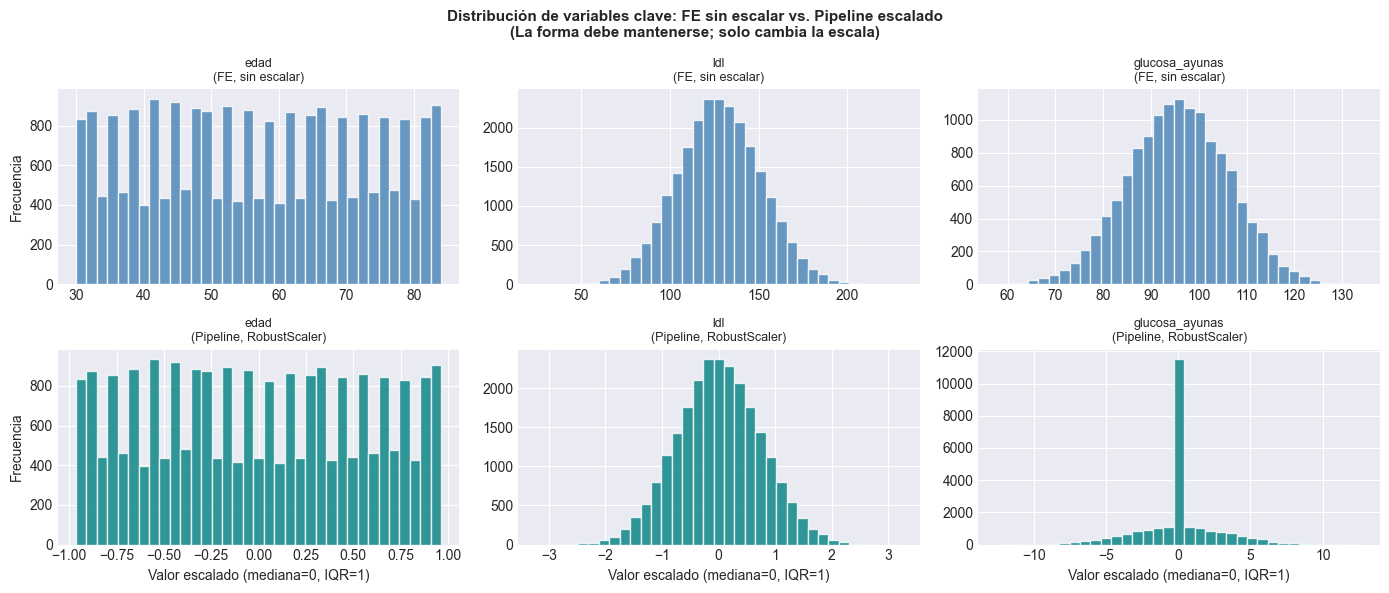

→ Confirmado: RobustScaler preserva la forma de las distribuciones.
  Solo desplaza la mediana a 0 y normaliza por IQR.


In [43]:
# ── Comparativa de distribuciones: raw vs. procesado ─────────────────────────
# Verificación visual: las distribuciones de las variables clave no deben
# distorsionarse significativamente tras el preprocesamiento.

vars_check = ['edad', 'ldl', 'presion_media', 'glucosa_ayunas']
# Filtrar las que existen en ambos datasets
vars_check = [v for v in vars_check if v in df_train.columns and v in df_train_fe.columns]

fig, axes = plt.subplots(2, len(vars_check), figsize=(14, 6))

for j, var in enumerate(vars_check):
    # Fila superior: versión FE (sin escalar)
    axes[0, j].hist(df_train_fe[var].dropna(), bins=35,
                    color='steelblue', alpha=0.8, edgecolor='white')
    axes[0, j].set_title(f'{var}\n(FE, sin escalar)', fontsize=9)
    axes[0, j].set_ylabel('Frecuencia' if j == 0 else '')

    # Fila inferior: versión pipeline (escalada con RobustScaler)
    axes[1, j].hist(df_train_pipeline[var].dropna(), bins=35,
                    color='teal', alpha=0.8, edgecolor='white')
    axes[1, j].set_title(f'{var}\n(Pipeline, RobustScaler)', fontsize=9)
    axes[1, j].set_ylabel('Frecuencia' if j == 0 else '')
    axes[1, j].set_xlabel('Valor escalado (mediana=0, IQR=1)')

plt.suptitle('Distribución de variables clave: FE sin escalar vs. Pipeline escalado\n'
             '(La forma debe mantenerse; solo cambia la escala)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_distribucion_raw_vs_scaled.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Confirmado: RobustScaler preserva la forma de las distribuciones.")
print("  Solo desplaza la mediana a 0 y normaliza por IQR.")